In [6]:
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt

In [7]:
# obtain the final gene list from the output csv file
outdir = 'Output'
Cancer =  'CRC'#"prostate_cancer" ,"CRC","LUAD"
fc_cutoff = 0
file_path = f"{outdir}/{Cancer}_final_gene_list_fc{fc_cutoff}.csv"
df_genes = pd.read_csv(file_path)
final_gene_list = df_genes.iloc[:, 0].dropna().tolist()
final_gene_list


['ZG16',
 'GSN',
 'MUC2',
 'GUCA2A',
 'BEST4',
 'SLC26A3',
 'AQP8',
 'OTOP2',
 'FCGBP',
 'ANKRD36C',
 'CA4',
 'PHGR1',
 'CA7',
 'TSPAN1',
 'CCL5',
 'GUCA2B',
 'LYPD8',
 'MUC1',
 'CD3D',
 'SH2D6',
 'NOTUM',
 'ITM2C',
 'LRMP',
 'ADH1C',
 'C15orf48',
 'SDCBP2',
 'FYB1',
 'CORO1A',
 'CA2',
 'CLCA4',
 'CEACAM7',
 'CD79B',
 'CD79A',
 'MYOM1',
 'EVL',
 'TCL1A',
 'NKD1',
 'SPIB',
 'ENTPD8',
 'AZGP1',
 'CD3E',
 'LGALS4',
 'CD52',
 'KLK12',
 'HRASLS2',
 'HPGD',
 'CD177',
 'BMP4',
 'SELENBP1',
 'ASCL2',
 'LAPTM5',
 'CTSE',
 'PKIB',
 'SOX4',
 'HCST',
 'GZMA',
 'CD7',
 'CDHR5',
 'HEPACAM2',
 'ST6GALNAC1',
 'CD37',
 'NDUFA4L2',
 'LDHA',
 'MT1G',
 'HIST1H4C',
 'TPSG1',
 'PTPRC',
 'ATP5MC1',
 'REG4',
 'ANXA4',
 'MS4A12',
 'PFN1',
 'MT1E',
 'HIST1H1C',
 'MEF2C',
 'BAMBI',
 'NKG7',
 'CHCHD10',
 'COX4I1',
 'SH2D7',
 'SLC26A2',
 'C2orf88',
 'MT1M',
 'LIMD2',
 'SECTM1',
 'AICDA',
 'HOTAIRM1',
 'LCP1',
 'CDHR2',
 'CLEC2D',
 'VAMP8',
 'DPEP1',
 'PLCG2',
 'VPREB3',
 'DCK',
 'VSIG2',
 'ERO1A',
 'CD3G',
 'S100A

In [8]:
gene_sets = ['MSigDB_Hallmark_2020'] 
# perform enrichment analysis using Enrichr and save the results to a CSV file
enr = gp.enrichr(
    gene_list=final_gene_list,
    gene_sets=gene_sets,
    organism='human', 
    cutoff=0.05
)
# only keep order by p value
enr.results = enr.results.sort_values(by='Adjusted P-value', ascending=True)
enr.results.to_csv(f"{outdir}/{Cancer}_enrichment_results_fc{fc_cutoff}.csv", index=False)
# only keep the significant results
enr.results = enr.results[enr.results['Adjusted P-value'] < 0.05]
print(enr.results[['Gene_set', 'Term', 'Adjusted P-value', 'Genes']].head(10))

# show all column names
print(enr.results.columns.tolist())
# save the enrichment results to a CSV file
enr.results.to_csv(f"{outdir}/{Cancer}_enrichment_results_fc{fc_cutoff}_significant.csv", index=False)


                Gene_set                       Term  Adjusted P-value  \
0   MSigDB_Hallmark_2020        Allograft Rejection      1.134210e-07   
1   MSigDB_Hallmark_2020       IL-2/STAT5 Signaling      4.525135e-04   
2   MSigDB_Hallmark_2020  Oxidative Phosphorylation      4.525135e-04   
3   MSigDB_Hallmark_2020          Androgen Response      2.234813e-03   
4   MSigDB_Hallmark_2020      Fatty Acid Metabolism      5.233246e-03   
5   MSigDB_Hallmark_2020          KRAS Signaling Up      5.233246e-03   
6   MSigDB_Hallmark_2020                    Hypoxia      1.610407e-02   
7   MSigDB_Hallmark_2020            heme Metabolism      1.610407e-02   
11  MSigDB_Hallmark_2020           mTORC1 Signaling      3.912449e-02   
10  MSigDB_Hallmark_2020            Apical Junction      3.912449e-02   

                                                Genes  
0   CD96;FYB1;GZMA;CD3G;CD3E;CD3D;CD79A;PTPRC;LCK;...  
1   CD79B;MUC1;CA2;ANXA4;IL3RA;RHOH;LTB;PHLDA1;NDR...  
2   COX8A;LDHA;ATP5F1A;MGST3

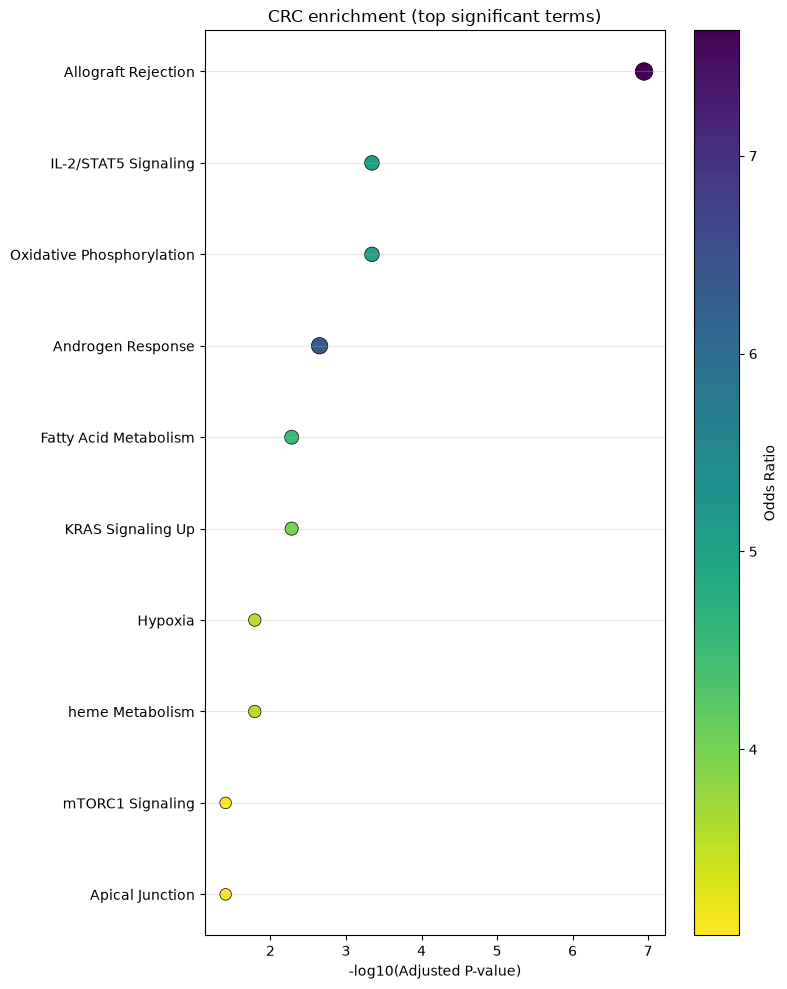

In [9]:
import numpy as np

def plot_enrichment_top_significant(df_results, out_png, title=None, top_n=10, figsize=(8, 10)):
    plot_df = df_results.copy()
    plot_df = plot_df[plot_df['Adjusted P-value'].notna()].copy()
    plot_df['neg_log10_adj_p'] = -np.log10(plot_df['Adjusted P-value'].clip(lower=1e-300))

    # Keep top-N most significant terms (smallest adjusted p-value).
    plot_df = plot_df.nsmallest(top_n, 'Adjusted P-value').copy()
    plot_df = plot_df.sort_values('Adjusted P-value', ascending=True).reset_index(drop=True)

    # Bubble size by % genes in set when Overlap is available.
    if 'Overlap' in plot_df.columns:
        overlap_num = plot_df['Overlap'].astype(str).str.split('/').str[0].astype(float)
        overlap_den = plot_df['Overlap'].astype(str).str.split('/').str[1].astype(float)
        plot_df['pct_genes_in_set'] = 100 * overlap_num / overlap_den
    else:
        plot_df['pct_genes_in_set'] = 10.0

    y = np.arange(len(plot_df))
    sizes = np.clip(plot_df['pct_genes_in_set'], 1, None) * 20

    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(
        plot_df['neg_log10_adj_p'],
        y,
        s=sizes,
        c=plot_df['Odds Ratio'],
        cmap='viridis_r',
        edgecolors='black',
        linewidths=0.5,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df['Term'])
    ax.invert_yaxis()  # index 0 (most significant) appears at top
    ax.set_xlabel('-log10(Adjusted P-value)')
    if title:
        ax.set_title(title)
    ax.grid(axis='y', linestyle='-', alpha=0.3)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Odds Ratio')

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.show()

plot_enrichment_top_significant(
    enr.results,
    f"{outdir}/{Cancer}_enrichment_dotplot_fc{fc_cutoff}.png",
    title=f"{Cancer} enrichment (top significant terms)",
    top_n=10,
    figsize=(8, 10),
)


                  Gene_set                Term  Adjusted P-value  \
0  DGIdb_Drug_Targets_2024           SULTHIAME          0.000900   
1  DGIdb_Drug_Targets_2024       ETHOXZOLAMIDE          0.000900   
2  DGIdb_Drug_Targets_2024      CHLOROTHIAZIDE          0.000900   
3  DGIdb_Drug_Targets_2024  TRICHLORMETHIAZIDE          0.001337   
4  DGIdb_Drug_Targets_2024        TANESPIMYCIN          0.001856   
5  DGIdb_Drug_Targets_2024       ACETAZOLAMIDE          0.005163   
6  DGIdb_Drug_Targets_2024          GANETESPIB          0.048123   

                    Genes  
0         CA1;CA2;CA4;CA7  
1         CA1;CA2;CA4;CA7  
2             CA1;CA2;CA4  
3             CA1;CA2;CA4  
4  HSP90AA1;HSP90AB1;GMNN  
5             CA1;CA2;CA4  
6       HSP90AA1;HSP90AB1  


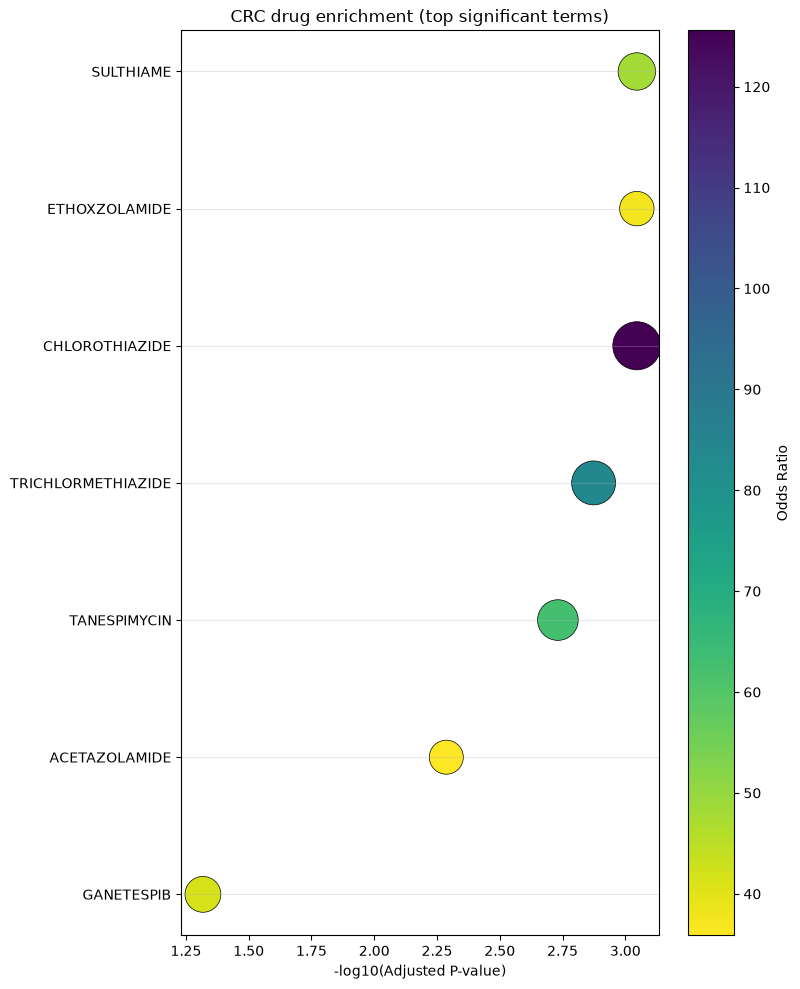

In [10]:
# perform drug enrichment analysis using Enrichr and save the results to a CSV file
drug_gene_sets = ['DGIdb_Drug_Targets_2024']
enr_drug = gp.enrichr(
    gene_list=final_gene_list,
    gene_sets=drug_gene_sets,
    organism='human',
    cutoff=0.05
)
# only keep order by p value
enr_drug.results = enr_drug.results.sort_values(by='Adjusted P-value', ascending=True)
enr_drug.results.to_csv(f"{outdir}/{Cancer}_drug_enrichment_results_fc{fc_cutoff}.csv", index=False)
# only keep the significant results
enr_drug.results = enr_drug.results[enr_drug.results['Adjusted P-value'] < 0.05]
print(enr_drug.results[['Gene_set', 'Term', 'Adjusted P-value', 'Genes']].head(10))
# save the drug enrichment results to a CSV file
enr_drug.results.to_csv(f"{outdir}/{Cancer}_drug_enrichment_results_fc{fc_cutoff}_significant.csv", index=False)

plot_enrichment_top_significant(
    enr_drug.results,
    f"{outdir}/{Cancer}_drug_enrichment_dotplot_fc{fc_cutoff}.png",
    title=f"{Cancer} drug enrichment (top significant terms)",
    top_n=10,
    figsize=(8, 10),
)
                  